In [2]:
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [24]:
b=2.0
# residual and objective function
F = lambda X,Y: np.array([1/b*np.exp(b*X)-Y, X**2+Y**2-1])
Phi = lambda X,Y: 0.5*np.linalg.norm(F(X,Y), axis=0)

# Jacobian
J = lambda x,y: np.array([[np.exp(b*x), -1], [2*x, 2*y]])

# line search length
def line_search_length(x0, x1, alpha_max=1.0):
    f = lambda alpha: Phi(x0[0] + alpha*(x1[0]-x0[0]), x0[1] + alpha*(x1[1]-x0[1]))
    return f(0.)/(f(1.) + f(0.)) if f(1.) > f(0.) else alpha_max

In [32]:
alpha = 1.0
alpha = .32
x0 = alpha * np.array([1.0, 1.0])

delta = np.linalg.solve(J(x0[0],x0[1]), -F(x0[0],x0[1]))
x1 = x0 + delta
lam = line_search_length(x0, x1)
print('lambda:', lam)
F1 = F(x0[0],x0[1])
delta = np.linalg.solve(J(x0[0],x0[1]), -F1)
print('residual F1:',  F1)
print('delta:', delta)
print('Phi(x0[0],x0[1]):', Phi(x0[0],x0[1]))
print('Phi(x1[0],x1[1]):', Phi(x1[0],x1[1]))

lambda: 0.4770001397350228
residual F1: [ 0.62824044 -0.7952    ]
delta: [0.21207099 1.03042901]
Phi(x0[0],x0[1]): 0.5067122186248166
Phi(x1[0],x1[1]): 0.5555772366912742


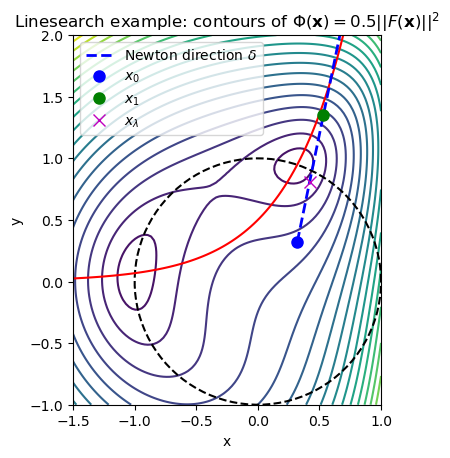

In [33]:
# Plot the contour and curves
x = np.linspace(-1.5,1.,100)
y = np.linspace(-1,2,100)
X,Y = np.meshgrid(x,y)

plt.contour(X, Y, Phi(X, Y), levels=20)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--')
plt.plot(x, 1/b*np.exp(b*x), 'r-')

# Plot line through point [1., 1.] in direction of delta
t = np.linspace(0, 5, 100)
line = lambda t: x0 + np.outer(t, delta)
#plt.quiver(x0[0], x0[1], -2*F1[0], -2*F1[1], angles='xy', scale_units='xy', color='y')
plt.plot(line(t)[:,0], line(t)[:,1], 'b--', linewidth=2, label='Newton direction $\\delta$')
plt.plot(x0[0], x0[1]   , 'bo', markersize=8, label='$x_{0}$')
plt.plot(line(1)[0,0], line(1)[0,1], 'go', markersize=8, label='$x_{1}$')
if lam < 1.0:
    plt.plot(x0[0] + lam*delta[0], x0[1] + lam*delta[1], 'mx', markersize=8, label='$x_{\\lambda}$')

plt.axis('square')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-1, 2)
plt.xlim(-1.5, 1)
plt.legend()
plt.title('Linesearch example: contours of $\\Phi(\\mathbf{x}) = 0.5 ||F(\\mathbf{x})||^2$')
plt.show()